# 00 Data Reality and Validity Check

Этот ноутбук — входная точка качества данных для BOQ. Он отвечает на вопрос: «достаточно ли реалистичен и согласован synthetic raw dataset, чтобы на него было не стыдно обучать ML‑модель?».

В этом ноутбуке мы:

- Загружаем `data/raw/synthetic_shows.csv` и проверяем, что все обязательные поля присутствуют и имеют ожидаемые типы.
- Валидируем базовые инварианты: `hall_capacity > 0`, `0 ≤ sold_tickets ≤ hall_capacity`, `occupancy_rate ≈ sold_tickets / hall_capacity`, `release_date ≤ show_datetime`.
- Строим sanity‑чарты (гистограммы, boxplot’ы) по `occupancy_rate`, `hour_bucket`, `genre`, `is_weekend`, `prime_time_flag`, чтобы поймать явно нереалистичные паттерны спроса.
- Фиксируем любые найденные «артефакты генератора» (например, слишком высокий спрос на horror утром) как TODO для следующей итерации синтетики.


## Навигация по ноутбуку

### Зачем нужен этот ноутбук
Этот ноутбук — входная точка контроля качества данных в проекте BOQ. Его задача — понять, достаточно ли реалистичен, согласован и пригоден synthetic raw dataset для дальнейшего ML и оптимизации расписания.

### Что здесь самое важное
- Проверить, что временные, категориальные и численные поля выглядят правдоподобно.
- Найти очевидные проблемы: пропуски, невозможные значения, аномальные распределения, потенциальный leakage.
- Зафиксировать, можно ли использовать текущий датасет как основу для последующих этапов.

### Какие результаты здесь ключевые
- Сводные диагностические характеристики raw dataset.
- Графики и sanity-check по главным бизнес-полям.
- Решение: продолжаем работу с данными или возвращаемся к генерации / очистке.

### Как читать этот ноутбук
Если вы впервые заходите в проект, начинать нужно отсюда. Если на этом этапе есть проблемы в данных, то все последующие ноутбуки будут наследовать те же искажения в прогнозе спроса и в оптимизации.


In [1]:
from __future__ import annotations

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'synthetic_shows.csv'

DATA_PATH

PosixPath('/Users/mishatrubik/Desktop/QC/BOQ/data/raw/synthetic_shows.csv')

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['show_datetime'])
df.head()

,show_id,cinema_id,hall_id,hall_capacity,movie_id,genre,age_rating,runtime_min,release_date,show_datetime,...,day_of_week,is_weekend,hour_bucket,month,holiday_flag,release_age_days,lead_time_days,prime_time_flag,runtime_bucket,screening_number_for_movie
0,show_00001,cinema_msk_01,hall_1,120,movie_family_01,animation,6+,92,2026-02-20,2026-03-01 10:30:00,...,6,True,morning,3,False,9,5.5,False,medium,1
1,show_00002,cinema_msk_01,hall_1,120,movie_family_01,animation,6+,92,2026-02-20,2026-03-01 14:15:00,...,6,True,day,3,False,9,13.8,True,medium,2
2,show_00003,cinema_msk_01,hall_2,80,movie_comedy_01,comedy,12+,105,2026-02-10,2026-03-01 10:45:00,...,6,True,morning,3,False,19,16.7,False,medium,1
3,show_00004,cinema_msk_01,hall_2,80,movie_dune_2,sci_fi,16+,166,2026-03-01,2026-03-01 14:30:00,...,6,True,day,3,False,0,9.8,True,long,1
4,show_00005,cinema_msk_01,hall_2,80,movie_dune_2,sci_fi,16+,166,2026-03-01,2026-03-01 18:45:00,...,6,True,evening,3,False,0,4.4,True,long,2


In [3]:
summary = {
    'rows': len(df),
    'columns': len(df.columns),
    'min_datetime': df['show_datetime'].min(),
    'max_datetime': df['show_datetime'].max(),
    'genres': sorted(df['genre'].dropna().unique().tolist()),
    'cities': sorted(df['city'].dropna().unique().tolist()),
}
summary

{'rows': 898,
 'columns': 25,
 'min_datetime': Timestamp('2026-03-01 10:15:00'),
 'max_datetime': Timestamp('2026-04-30 21:15:00'),
 'genres': ['animation', 'comedy', 'horror', 'sci_fi'],
 'cities': ['Moscow', 'Saint Petersburg']}

In [4]:
quality_checks = {
    'capacity_leq_zero': int((df['hall_capacity'] <= 0).sum()),
    'sold_negative': int((df['sold_tickets'] < 0).sum()),
    'sold_gt_capacity': int((df['sold_tickets'] > df['hall_capacity']).sum()),
    'release_after_show': int((pd.to_datetime(df['release_date']) > df['show_datetime']).sum()),
    'occupancy_formula_mismatch_gt_1e_3': int((((df['sold_tickets'] / df['hall_capacity']) - df['occupancy_rate']).abs() > 1e-3).sum()),
}
quality_checks

{'capacity_leq_zero': 0,
 'sold_negative': 0,
 'sold_gt_capacity': 0,
 'release_after_show': 12,
 'occupancy_formula_mismatch_gt_1e_3': 0}

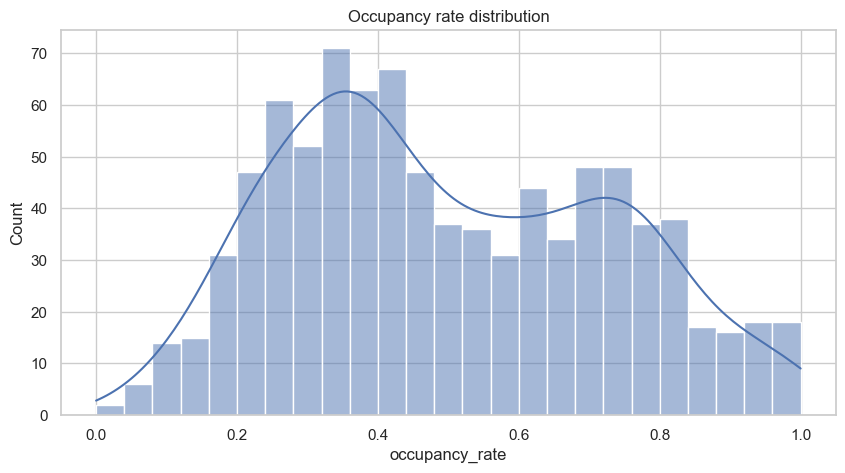

In [5]:
fig, ax = plt.subplots()
sns.histplot(df['occupancy_rate'], bins=25, kde=True, ax=ax)
ax.set_title('Occupancy rate distribution')
plt.show()

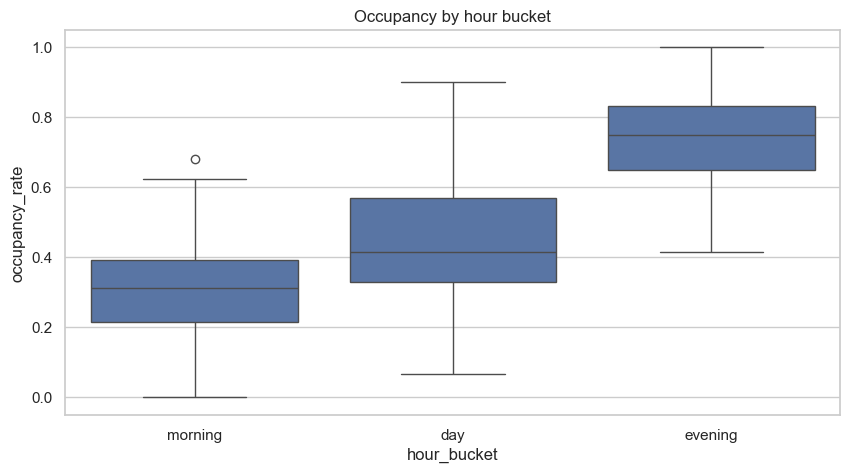

In [6]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='hour_bucket', y='occupancy_rate', order=['morning', 'day', 'evening'], ax=ax)
ax.set_title('Occupancy by hour bucket')
plt.show()

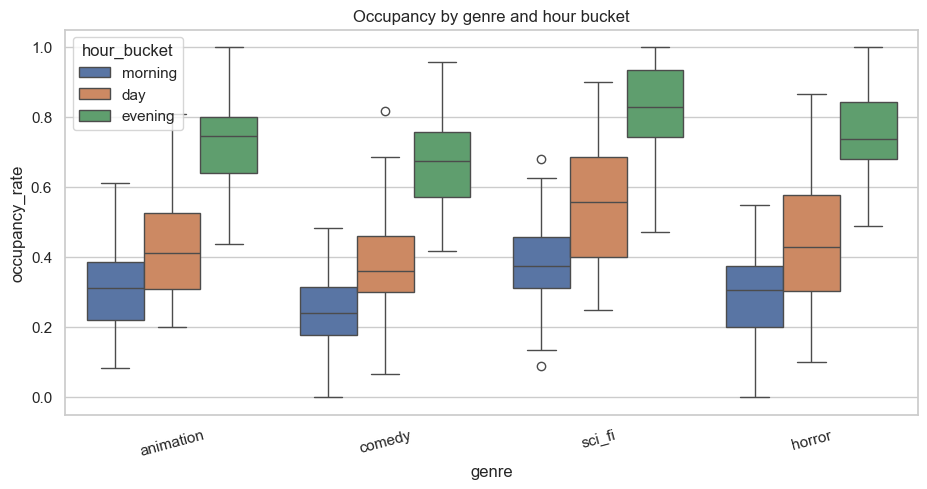

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x='genre', y='occupancy_rate', hue='hour_bucket', hue_order=['morning', 'day', 'evening'], ax=ax)
ax.set_title('Occupancy by genre and hour bucket')
plt.xticks(rotation=15)
plt.show()

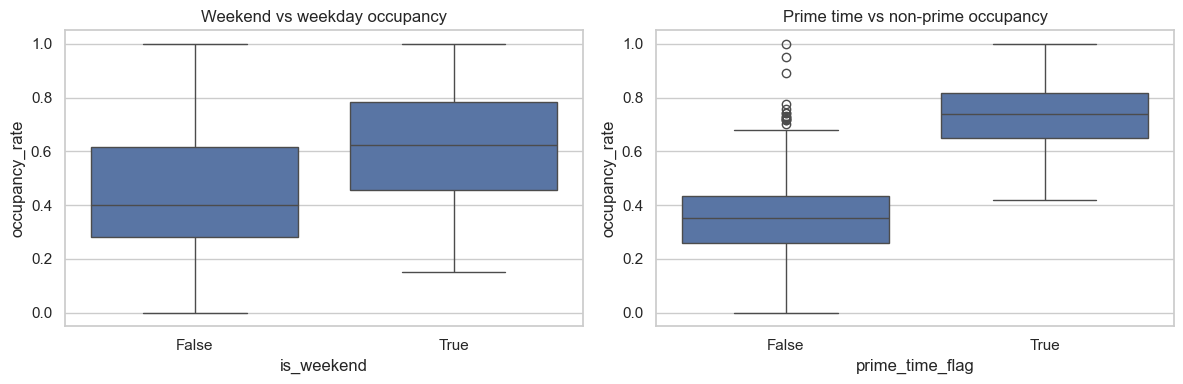

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='is_weekend', y='occupancy_rate', ax=axes[0])
axes[0].set_title('Weekend vs weekday occupancy')
sns.boxplot(data=df, x='prime_time_flag', y='occupancy_rate', ax=axes[1])
axes[1].set_title('Prime time vs non-prime occupancy')
plt.tight_layout()
plt.show()

In [9]:
horror_slice = (
    df[df['genre'] == 'horror']
    .groupby('hour_bucket')['occupancy_rate']
    .agg(['count', 'mean', 'min', 'max'])
    .reindex(['morning', 'day', 'evening'])
)

horror_slice

,count,mean,min,max
hour_bucket,,,,
morning,68,0.299044,0.00,0.5500
day,87,0.451155,0.10,0.8667
evening,84,0.749914,0.49,1.0000
